In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPT2Model, GPT2Tokenizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import tree

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2Model.from_pretrained("gpt2",
                                   output_hidden_states=True)
model.eval()

print("Ready!")

c:\Users\devuser3\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 4831.47it/s]

Ready!


In [2]:

positive_sentences = [
    "This movie was absolutely wonderful and amazing",
    "I love this beautiful sunny day",
    "The food was delicious and fantastic",
    "She is a brilliant and talented person",
    "This book is incredible and inspiring",
    "What a gorgeous and perfect day",
    "The concert was spectacular and enjoyable",
    "I am so happy and excited today",
    "This is the best experience ever",
    "Everything is going great and wonderful",
]

negative_sentences = [
    "This movie was absolutely terrible and boring",
    "I hate this cold and gloomy day",
    "The food was disgusting and awful",
    "She is a terrible and incompetent person",
    "This book is horrible and depressing",
    "What an ugly and miserable day",
    "The concert was dreadful and painful",
    "I am so sad and disappointed today",
    "This is the worst experience ever",
    "Everything is going wrong and terrible",
]

all_sentences = positive_sentences + negative_sentences
all_labels    = [1]*10 + [0]*10  # 1=positive, 0=negative

print(f"Total sentences: {len(all_sentences)}")
print(f"Positive: {sum(all_labels)}")
print(f"Negative: {len(all_labels) - sum(all_labels)}")

Total sentences: 20
Positive: 10
Negative: 10


In [3]:
def get_sentence_embedding(text, layer_idx=-1):
    inputs = tokenizer(text, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.hidden_states[layer_idx][0].mean(dim=0).numpy()


print("Decision Tree per Layer:")
print(f"\n{'Layer':<10} {'Accuracy'}")
print("-"*25)

layer_accs = []

for layer_idx in range(13):
    X = np.array([get_sentence_embedding(s, layer_idx)
                  for s in all_sentences])
    y = np.array(all_labels)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y)

    dt = DecisionTreeClassifier(max_depth=3, random_state=42)
    dt.fit(X_train, y_train)
    acc = accuracy_score(y_test, dt.predict(X_test))
    layer_accs.append(acc)

    label = "Emb" if layer_idx == 0 else f"L{layer_idx}"
    print(f"{label:<10} {acc*100:.1f}%")

best_layer = np.argmax(layer_accs)
print(f"\nBest layer: {'Emb' if best_layer==0 else f'L{best_layer}'} "
      f"({max(layer_accs)*100:.1f}%)")

Decision Tree per Layer:

Layer      Accuracy
-------------------------
Emb        66.7%
L1         66.7%
L2         33.3%
L3         50.0%
L4         66.7%
L5         83.3%
L6         66.7%
L7         83.3%
L8         83.3%
L9         66.7%
L10        66.7%
L11        66.7%
L12        83.3%

Best layer: L5 (83.3%)


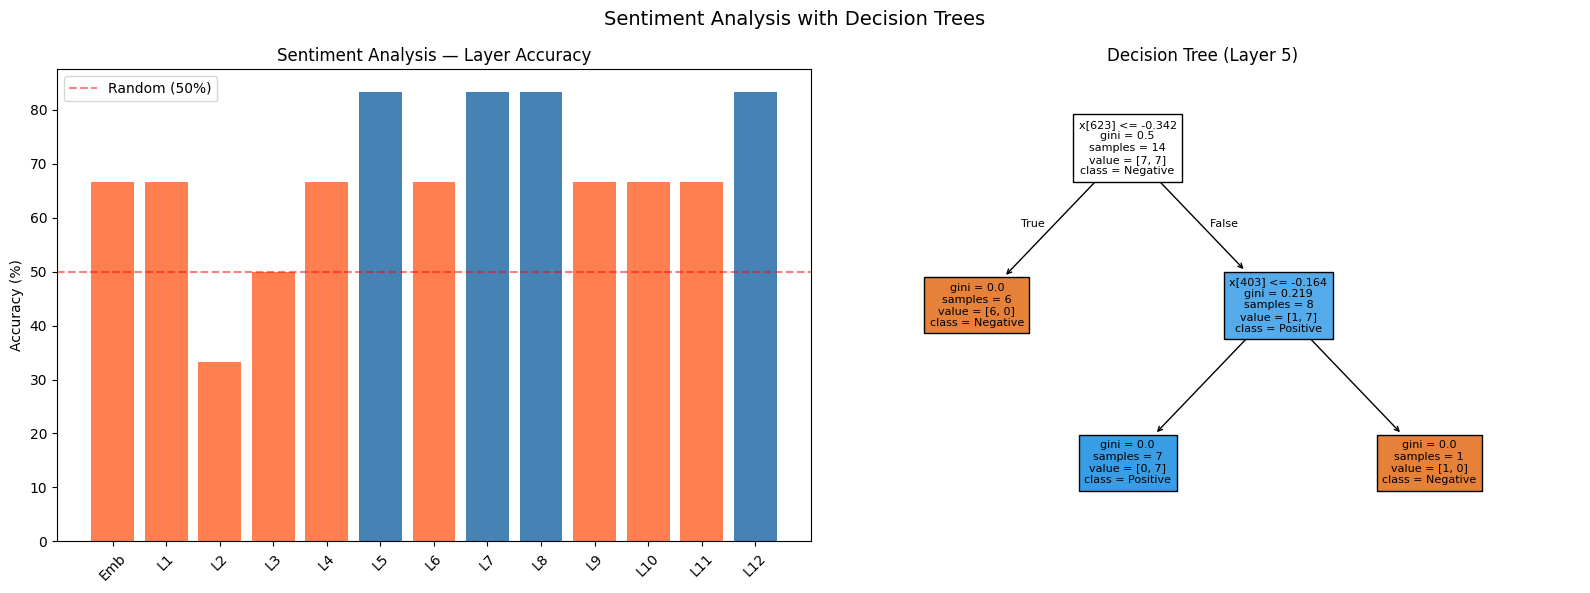

In [4]:
X = np.array([get_sentence_embedding(s, 5)
              for s in all_sentences])
y = np.array(all_labels)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy per layer
x       = range(13)
xlabels = ["Emb"] + [f"L{i}" for i in range(1, 13)]
colors  = ["steelblue" if a >= 0.8 else "coral"
           for a in layer_accs]

axes[0].bar(x, [a*100 for a in layer_accs], color=colors)
axes[0].axhline(y=50, color="red", linestyle="--",
                alpha=0.5, label="Random (50%)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(xlabels, rotation=45)
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Sentiment Analysis — Layer Accuracy")
axes[0].legend()

# Decision tree plot
tree.plot_tree(dt, max_depth=2,
               class_names=["Negative", "Positive"],
               filled=True, ax=axes[1],
               fontsize=8)
axes[1].set_title("Decision Tree (Layer 5)")

plt.suptitle("Sentiment Analysis with Decision Trees", fontsize=14)
plt.tight_layout()
plt.show()


* GPT-2 embeddings contain sentiment information.
* Layers 5, 7, 8, and 12 achieve 83.3% accuracy.
* Layer 2 achieves 33% — worse than random (due to compression effect).
* Decision Tree provides a visual explanation of the predictions.
